# Clasificación multiclase — Caracteres Hangul (coreano) escritos a mano

## Introducción

Este cuaderno es una **adaptación** del ejercicio original de regresión logística *one-vs-all* (originalmente aplicado a los dígitos escritos a mano del dataset MNIST/`ex3data1.mat`) para trabajar con el dataset de Kaggle:

**[Handwritten Hangul Korean Syllables 손으로 쓴 음절](https://www.kaggle.com/datasets/jkim289/handwritten-korean-characters)**

Este dataset contiene **64 clases** de sílabas Hangul escritas a mano (100 muestras originales por clase, aumentadas hasta 2000 muestras por clase mediante *data augmentation*).

La lógica matemática del ejercicio (función de costo regularizada, gradiente vectorizado, entrenamiento *one-vs-all* y predicción) **no cambia**: solo cambia la forma en que se cargan y preprocesan los datos, porque en vez de partir de un archivo `.mat` con imágenes de 20x20 ya aplanadas, aquí partimos de imágenes `.png`/`.jpg` organizadas en carpetas (una carpeta por clase/sílabo), que hay que leer, redimensionar y aplanar nosotros mismos.

Antes de empezar, se importan todas las librerías necesarias.

In [34]:
# utilizado para la manipulación de directorios y rutas
import os
import glob
import random

# Cálculo científico y vectorial para python
import numpy as np

# Libreria para graficos
from matplotlib import pyplot
import matplotlib

# Modulo de optimizacion en scipy
from scipy import optimize

# Para leer imágenes (png/jpg) y redimensionarlas
from PIL import Image

# Para codificar las etiquetas (nombres de sílabas) como enteros y separar train/test
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

## 0. Obtener el dataset

Hay dos formas típicas de conseguir el dataset dentro de este cuaderno:

1. **Google Colab + Google Drive**: descargar el dataset una vez desde Kaggle, subirlo a Google Drive, y montar el Drive (igual que en el cuaderno original de dígitos).
2. **`kagglehub`** (recomendado, funciona tanto en Colab como en local): descarga el dataset directamente desde Kaggle la primera vez que se ejecuta y lo deja cacheado.

Se implementan ambas opciones; usa la que te resulte más cómoda y deja la otra comentada. Si usas la opción de `kagglehub` necesitas tener configuradas tus credenciales de Kaggle (`kaggle.json`) o, en Colab, iniciar sesión cuando se te solicite.

In [35]:
DATA_DIR = r'd:\sis420\machine learning\lab2026\lab5\Hangul Database'
print('Usando dataset local en:', DATA_DIR)

Usando dataset local en: d:\sis420\machine learning\lab2026\lab5\Hangul Database


## 1 Clasificación multiclase

Se usará regresión logística (y, en un ejercicio posterior, redes neuronales) para reconocer **sílabas Hangul** escritas a mano. La idea es idéntica al reconocimiento de dígitos manuscritos, solo que en vez de 10 clases (dígitos 0-9) ahora se tienen **64 clases** (sílabas coreanas), y en vez de imágenes de 20x20 píxeles ya aplanadas en un `.mat`, se parte de archivos de imagen individuales organizados en carpetas.

### 1.1 Dataset

El dataset de Kaggle, una vez descargado, sigue típicamente una estructura de tipo *ImageFolder*: una carpeta por clase, y dentro de cada carpeta las imágenes `.png`/`.jpg` correspondientes a esa sílaba, por ejemplo:

```
DATA_DIR/
├── 가/
│   ├── 가_001.png
│   ├── 가_002.png
│   └── ...
├── 나/
│   ├── 나_001.png
│   └── ...
└── ...
```

**Importante:** la estructura exacta de carpetas puede variar levemente según cómo Kaggle empaquete el dataset (por ejemplo, puede haber una carpeta intermedia `raw/` u `augmented/`, o los nombres de las clases pueden venir en romanización en vez de Hangul). La función `load_hangul_dataset` de abajo es **agnóstica a esos detalles**: recorre recursivamente `DATA_DIR`, encuentra todos los archivos de imagen, y usa el **nombre de la carpeta que contiene directamente cada imagen** como etiqueta de clase. Antes de entrenar, revisa la celda de diagnóstico que imprime cuántas clases y cuántas imágenes por clase se detectaron, para confirmar que la estructura se interpretó correctamente.

In [36]:
def load_hangul_dataset(data_dir, img_size=32, max_per_class=None, seed=42):
    '''
    Recorre `data_dir` recursivamente, carga cada imagen encontrada, la convierte
    a escala de grises, la redimensiona a (img_size x img_size) y la aplana en un
    vector 1D normalizado en [0, 1]. La etiqueta de cada imagen es el nombre de la
    carpeta que la contiene directamente (una carpeta = una clase/sílaba).

    Parametros
    ----------
    data_dir : str
        Carpeta raíz del dataset ya descomprimido.
    img_size : int
        Tamaño (ancho = alto) al que se redimensiona cada imagen.
    max_per_class : int or None
        Si se especifica, se toma como máximo esa cantidad de imágenes por clase
        (muestreadas aleatoriamente). Útil para acelerar el entrenamiento, ya que
        este dataset puede tener miles de imágenes aumentadas por clase.
    seed : int
        Semilla para el muestreo aleatorio reproducible.

    Devuelve
    -------
    X : array_like, shape (m, img_size*img_size)
        Matriz de datos, cada fila es una imagen aplanada.
    y_labels : array_like, shape (m,)
        Etiquetas (nombres de las sílabas) como strings, una por fila de X.
    '''
    exts = ('*.png', '*.jpg', '*.jpeg', '*.bmp')
    all_paths = []
    for ext in exts:
        all_paths.extend(glob.glob(os.path.join(data_dir, '**', ext), recursive=True))

    if len(all_paths) == 0:
        raise FileNotFoundError(
            f'No se encontraron imágenes dentro de {data_dir}. '
            'Verifica que DATA_DIR apunte a la carpeta correcta del dataset ya descomprimido.'
        )

    # Agrupa las rutas por carpeta contenedora (= clase)
    by_class = {}
    for p in all_paths:
        label = os.path.basename(os.path.dirname(p))
        by_class.setdefault(label, []).append(p)

    rng = random.Random(seed)
    X_list, y_list = [], []
    for label, paths in sorted(by_class.items()):
        if max_per_class is not None and len(paths) > max_per_class:
            paths = rng.sample(paths, max_per_class)
        for p in paths:
            img = Image.open(p).convert('L').resize((img_size, img_size))
            arr = np.asarray(img, dtype=np.float64) / 255.0
            X_list.append(arr.flatten())
            y_list.append(label)

    X = np.array(X_list)
    y_labels = np.array(y_list)
    return X, y_labels


In [37]:
# Tamaño al que se redimensiona cada imagen (analogo a los 20x20 del dataset de digitos)
img_size = 32
input_layer_size = img_size * img_size

# Limita la cantidad de imagenes por clase para que el entrenamiento sea rapido.
# Sube este numero (o ponlo en None para usar todas las ~2000 imagenes por clase)
# si quieres mas precision a costa de mas tiempo de entrenamiento.
max_per_class = 200

X, y_labels = load_hangul_dataset(DATA_DIR, img_size=img_size, max_per_class=max_per_class)

print('X shape:', X.shape)
print('y shape:', y_labels.shape)

clases, conteos = np.unique(y_labels, return_counts=True)
num_labels = len(clases)
print(f'Numero de clases detectadas: {num_labels}')
print('Ejemplos por clase (min, max):', conteos.min(), conteos.max())


X shape: (6400, 1024)
y shape: (6400,)
Numero de clases detectadas: 64
Ejemplos por clase (min, max): 100 100


### 1.2 Codificación de etiquetas y separación train/test

A diferencia del dataset de dígitos (donde `y` ya venía como enteros 0-9), aquí las etiquetas son los nombres de las sílabas Hangul (strings). Se usa `LabelEncoder` de `scikit-learn` para convertirlas a enteros `0..num_labels-1`, que es el formato que espera el resto del código (`oneVsAll`, `predictOneVsAll`).

También se separa el conjunto en entrenamiento y prueba (80% / 20%) para poder medir qué tan bien generaliza el clasificador a imágenes que no vio durante el entrenamiento — el cuaderno original solo medía precisión sobre el conjunto de entrenamiento, lo cual sobreestima el desempeño real.

In [38]:
le = LabelEncoder()
y = le.fit_transform(y_labels)
class_names = le.classes_  # class_names[i] -> silaba Hangul correspondiente a la etiqueta entera i

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

m = y_train.size
print('Entrenamiento:', X_train.shape, y_train.shape)
print('Prueba       :', X_test.shape, y_test.shape)


Entrenamiento: (5120, 1024) (5120,)
Prueba       : (1280, 1024) (1280,)


### 1.3 Visualización de los datos

Igual que en el cuaderno original, se visualiza un subconjunto aleatorio del conjunto de entrenamiento. La función `displayData` se adapta para reconstruir imágenes cuadradas de `img_size x img_size` a partir de cada fila de `X` (aquí las imágenes se aplanaron en orden "C" / por filas, a diferencia del dataset `.mat` original que usaba orden Fortran, así que el `reshape` dentro de `displayData` se ajusta en consecuencia).

In [39]:
def displayData(X, example_width=None, figsize=(10, 10), titles=None):
    '''
    Muestra datos 2D almacenados en X (filas = imagenes aplanadas) en una cuadricula.
    Opcionalmente, `titles` es una lista de strings (una por fila de X) que se
    usa como titulo de cada subplot (por ejemplo, la silaba real o predicha).
    '''
    if X.ndim == 2:
        m, n = X.shape
    elif X.ndim == 1:
        n = X.size
        m = 1
        X = X[None]
    else:
        raise IndexError('La entrada X debe ser 1 o 2 dimensional.')

    example_width = example_width or int(np.round(np.sqrt(n)))
    example_height = n // example_width

    display_rows = int(np.floor(np.sqrt(m)))
    display_cols = int(np.ceil(m / display_rows))

    fig, ax_array = pyplot.subplots(display_rows, display_cols, figsize=figsize)
    fig.subplots_adjust(wspace=0.1, hspace=0.3)

    ax_array = [ax_array] if m == 1 else ax_array.ravel()

    for i, ax in enumerate(ax_array):
        if i < m:
            # orden 'C' (por filas), ya que asi se aplanaron las imagenes al cargarlas
            ax.imshow(X[i].reshape(example_height, example_width),
                      cmap='Greys', extent=[0, 1, 0, 1])
            if titles is not None and i < len(titles):
                ax.set_title(str(titles[i]), fontsize=9)
        ax.axis('off')


In [40]:
# Fuente con soporte para caracteres Hangul, para que los titulos se vean
# correctamente en vez de mostrar cuadros vacios. Es opcional: si falla,
# los graficos igual funcionan, solo que los titulos con Hangul podrian no
# renderizarse bien.
try:
    import matplotlib.font_manager as fm
    korean_fonts = [f.name for f in fm.fontManager.ttflist
                    if any(k in f.name for k in ['Nanum', 'Malgun', 'Gothic', 'Batang'])]
    if korean_fonts:
        matplotlib.rcParams['font.family'] = korean_fonts[0]
        print('Usando fuente:', korean_fonts[0])
    else:
        print('No se encontro una fuente con soporte Hangul instalada.')
        print('En Colab puedes instalar una con: !apt-get -qq install fonts-nanum y luego reiniciar el kernel.')
except Exception as e:
    print('No se pudo configurar una fuente Hangul:', e)


Usando fuente: Copperplate Gothic Bold


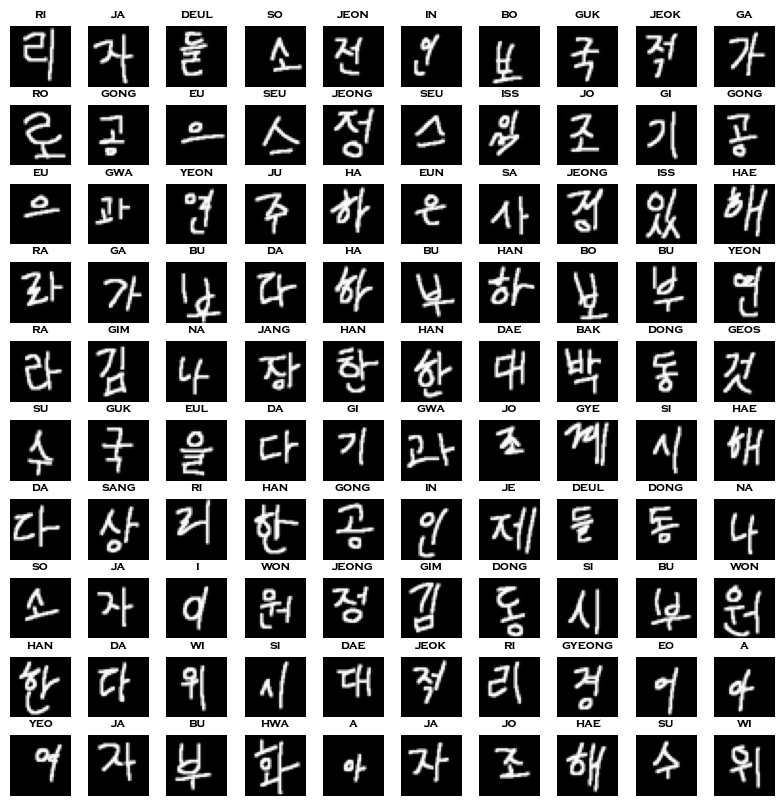

In [41]:
# Selecciona aleatoriamente 100 puntos de datos del conjunto de entrenamiento
rand_indices = np.random.choice(X_train.shape[0], 100, replace=False)
sel = X_train[rand_indices, :]
sel_labels = [class_names[i] for i in y_train[rand_indices]]

displayData(sel, example_width=img_size, titles=sel_labels)


### 1.4 Vectorización de regresión logística

Esta parte es **idéntica** al cuaderno original: se implementa una versión vectorizada (sin bucles `for`) de la función de costo de la regresión logística regularizada y su gradiente. La matemática no depende del dataset, así que estas funciones se reutilizan sin cambios.

$$ J(\theta) = \frac{1}{m} \sum_{i=1}^m \left[ -y^{(i)} \log \left( h_\theta\left( x^{(i)} \right) \right) - \left(1 - y^{(i)} \right) \log \left(1 - h_\theta \left( x^{(i)} \right) \right) \right] + \frac{\lambda}{2m} \sum_{j=1}^n \theta_j^2 $$

In [42]:
def sigmoid(z):
    '''
    Calcula la sigmoide de z.
    '''
    return 1.0 / (1.0 + np.exp(-z))


In [43]:
def lrCostFunction(theta, X, y, lambda_):
    '''
    Calcula el costo de usar theta como parametro para la regresion logistica
    regularizada y el gradiente del costo w.r.t. a los parametros.

    Parametros
    ----------
    theta : array_like, shape (n,)
    X : array_like, shape (m, n)
    y : array_like, shape (m,)
    lambda_ : float

    Devuelve
    -------
    J : float
    grad : array_like, shape (n,)
    '''
    m = y.size

    if y.dtype == bool:
        y = y.astype(int)

    h = sigmoid(X.dot(theta.T))

    temp = theta.copy()
    temp[0] = 0

    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h))) + (lambda_ / (2 * m)) * np.sum(np.square(temp))

    grad = (1 / m) * (h - y).dot(X)
    grad = grad + (lambda_ / m) * temp

    return J, grad


Se verifica la implementación con los mismos datos de prueba del cuaderno original (esto no depende del dataset de dígitos ni del de Hangul, es solo una prueba unitaria de la función).

In [44]:
# valores de prueba para los parametros theta
theta_t = np.array([-2, -1, 1, 2], dtype=float)

# valores de prueba para las entradas
X_t = np.concatenate([np.ones((5, 1)), np.arange(1, 16).reshape(5, 3, order='F') / 10.0], axis=1)

# valores de testeo para las etiquetas
y_t = np.array([1, 0, 1, 0, 1])

# valores de testeo para el parametro de regularizacion
lambda_t = 3

J, grad = lrCostFunction(theta_t, X_t, y_t, lambda_t)

print('Costo          : {:.6f}'.format(J))
print('Costo esperado : 2.534819')
print('-----------------------')
print('Gradientes:')
print(' [{:.6f}, {:.6f}, {:.6f}, {:.6f}]'.format(*grad))
print('Gradientes esperados:')
print(' [0.146561, -0.548558, 0.724722, 1.398003]')


Costo          : 2.534819
Costo esperado : 2.534819
-----------------------
Gradientes:
 [0.146561, -0.548558, 0.724722, 1.398003]
Gradientes esperados:
 [0.146561, -0.548558, 0.724722, 1.398003]


### 1.5 Clasificación One-vs-all

Se entrenan `num_labels` (aquí, **64**, una por cada sílaba Hangul) clasificadores de regresión logística regularizada, uno contra todos. La función `oneVsAll` tampoco cambia respecto al cuaderno original: es completamente genérica en `num_labels`, así que funciona igual de bien con 10 clases (dígitos) que con 64 (sílabas).

Como ahora hay más clases, más características por imagen y potencialmente más ejemplos, el entrenamiento tomará más tiempo que con el dataset de dígitos. Si quieres iterar más rápido mientras pruebas, reduce `max_per_class` en la celda de carga de datos, o reduce `img_size`.

In [45]:
def oneVsAll(X, y, num_labels, lambda_, maxiter=50):
    '''
    Entrena num_labels clasificadores de regresion logistica y devuelve cada uno
    de ellos en una matriz all_theta, donde la fila i-esima de all_theta
    corresponde al clasificador para la etiqueta i.

    Parametros
    ----------
    X : array_like, shape (m, n)
    y : array_like, shape (m,)
    num_labels : int
    lambda_ : float
    maxiter : int
        Numero maximo de iteraciones del optimizador por cada clasificador.

    Devuelve
    -------
    all_theta : array_like, shape (num_labels, n+1)
    '''
    m, n = X.shape

    all_theta = np.zeros((num_labels, n + 1))

    X = np.concatenate([np.ones((m, 1)), X], axis=1)

    for c in np.arange(num_labels):
        initial_theta = np.zeros(n + 1)
        options = {'maxiter': maxiter}
        res = optimize.minimize(lrCostFunction,
                                 initial_theta,
                                 (X, (y == c), lambda_),
                                 jac=True,
                                 method='CG',
                                 options=options)

        all_theta[c] = res.x

    return all_theta


In [46]:
lambda_ = 0.1
all_theta = oneVsAll(X_train, y_train, num_labels, lambda_, maxiter=80)


#### 1.5.1 Predicción One-vs-all

Igual que en el cuaderno original: para cada ejemplo se calcula la probabilidad de pertenecer a cada una de las 64 clases con los clasificadores entrenados, y se elige la clase con la probabilidad más alta.

In [47]:
def predictOneVsAll(all_theta, X):
    '''
    Devuelve un vector de predicciones para cada ejemplo en la matriz X, usando
    los clasificadores one-vs-all entrenados en all_theta.

    Parametros
    ----------
    all_theta : array_like, shape (num_labels, n+1)
    X : array_like, shape (m, n)

    Devuelve
    -------
    p : array_like, shape (m,)
    '''
    m = X.shape[0]

    X = np.concatenate([np.ones((m, 1)), X], axis=1)
    p = np.argmax(sigmoid(X.dot(all_theta.T)), axis=1)

    return p


Se evalúa la precisión tanto en el conjunto de **entrenamiento** como en el conjunto de **prueba** (que el modelo no vio durante el entrenamiento). Con un modelo lineal simple como este, es normal que la precisión sea bastante menor que la del ejemplo de dígitos MNIST (95%): los caracteres Hangul son visualmente más complejos, hay 64 clases en vez de 10, y una regresión logística por sí sola tiene un límite de decisión lineal. Un modelo no lineal (por ejemplo, una red neuronal o una CNN) normalmente da resultados bastante mejores en este tipo de datos.

In [48]:
pred_train = predictOneVsAll(all_theta, X_train)
pred_test = predictOneVsAll(all_theta, X_test)

print('Precision en entrenamiento: {:.2f}%'.format(np.mean(pred_train == y_train) * 100))
print('Precision en prueba       : {:.2f}%'.format(np.mean(pred_test == y_test) * 100))


Precision en entrenamiento: 99.61%
Precision en prueba       : 62.34%


Finalmente, se muestran algunos ejemplos del conjunto de prueba junto con la sílaba real y la sílaba predicha por el modelo, igual que la inspección visual que se hacía al final del cuaderno original.

Aciertos en esta muestra: 7/12


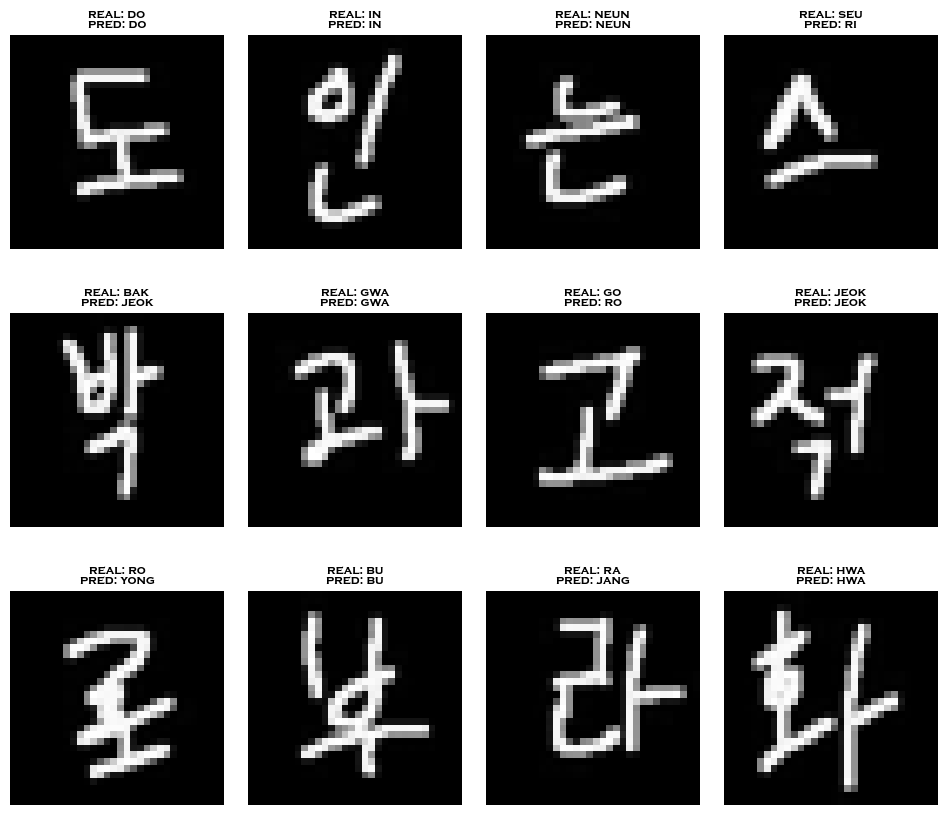

In [49]:
n_muestras = 12
idx = np.random.choice(X_test.shape[0], n_muestras, replace=False)

XPrueba = X_test[idx, :]
y_real = y_test[idx]
y_pred = predictOneVsAll(all_theta, XPrueba)

titulos = [f'real: {class_names[r]}\npred: {class_names[p]}' for r, p in zip(y_real, y_pred)]

print('Aciertos en esta muestra: {}/{}'.format(np.sum(y_real == y_pred), n_muestras))

displayData(XPrueba, example_width=img_size, figsize=(12, 10), titles=titulos)
